<a href="https://colab.research.google.com/github/Yash-Agarwal-4a5h/cei-assignments-yash-agarwal-jecrc-college/blob/main/week2_yash_agarwal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Load Dataset...

In [ ]:
df=pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Dataset Overview

In [ ]:
print("Shape :",df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape : (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


# Data Preprocessing

In [ ]:
# Missing Values
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [ ]:
# Describe Data
print(df.describe)

<bound method NDFrame.describe of       Year  Month         Region       Model  Estimated_Deliveries  \
0     2023      5         Europe     Model S                 17646   
1     2015      2           Asia     Model X                  3797   
2     2019      1  North America     Model X                  8411   
3     2021      2  North America     Model 3                  6555   
4     2016     12    Middle East     Model Y                 12374   
...    ...    ...            ...         ...                   ...   
2635  2021     10    Middle East     Model Y                 13488   
2636  2019      7    Middle East     Model S                 18300   
2637  2019      9           Asia     Model S                 13291   
2638  2020      5           Asia  Cybertruck                  3471   
2639  2018      8  North America     Model S                  2639   

      Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0                17922       92874.27               

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [ ]:
# import LabelEncoder and StandardScaler for convert categorical attributes into numerical attributes
from sklearn.preprocessing import LabelEncoder, StandardScaler


# ── Date feature ──
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(Day=1))

# ── Label encode categoricals ──
le_region = LabelEncoder()
le_model  = LabelEncoder()
le_src    = LabelEncoder()
df['Region_enc'] = le_region.fit_transform(df['Region'])
df['Model_enc']  = le_model.fit_transform(df['Model'])
df['Source_enc'] = le_src.fit_transform(df['Source_Type'])

print('\nData types after preprocessing:')
print(df.dtypes)
df.describe()
df.head()


Data types after preprocessing:
Year                             int64
Month                            int64
Region                          object
Model                           object
Estimated_Deliveries             int64
Production_Units                 int64
Avg_Price_USD                  float64
Battery_Capacity_kWh             int64
Range_km                         int64
CO2_Saved_tons                 float64
Source_Type                     object
Charging_Stations                int64
Date                    datetime64[ns]
Region_enc                       int64
Model_enc                        int64
Source_enc                       int64
dtype: object


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Region_enc,Model_enc,Source_enc
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,1,2,1
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,0,3,2
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,3,3,1
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,3,1,2
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,2,4,0


### Duplicates Records

In [ ]:
print(f'Duplicated rows:{df.duplicated().sum()}')

Duplicated rows:0


# Feature Engineering

In [ ]:
# Delivery-to-production efficiency ratio
df['Delivery_Production_Ratio'] = df['Estimated_Deliveries'] / df['Production_Units']

# Lag features for time-aware modeling
df_sorted = df.sort_values(['Region', 'Model', 'Year', 'Month'])
df['Lag1_Deliveries'] = df_sorted.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
df['Lag3_Deliveries'] = df_sorted.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(3)

# YoY growth rate (per region+model group)
df['YoY_Growth'] = df_sorted.groupby(['Region', 'Model'])['Estimated_Deliveries'].pct_change(periods=12)

print('New features added:', ['Delivery_Production_Ratio', 'Lag1_Deliveries', 'Lag3_Deliveries', 'YoY_Growth'])
df.head()

New features added: ['Delivery_Production_Ratio', 'Lag1_Deliveries', 'Lag3_Deliveries', 'YoY_Growth']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Region_enc,Model_enc,Source_enc,Delivery_Production_Ratio,Lag1_Deliveries,Lag3_Deliveries,YoY_Growth
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,1,2,1,0.984600,4669.0,8847.0,6.973791
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,0,3,2,0.911864,7292.0,NaN,NaN
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,3,3,1,0.915334,9743.0,8168.0,-0.239237
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,3,1,2,0.896594,4497.0,10557.0,-0.425202
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,2,4,0,0.914087,9894.0,11327.0,0.696463


# EDA with visualization

In [ ]:
# Import Required libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

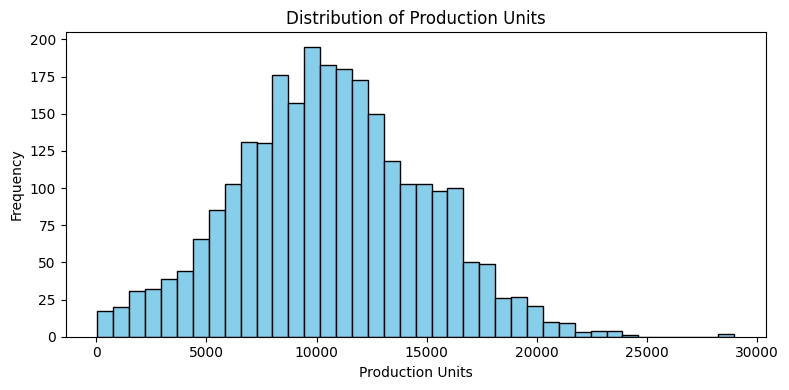

In [ ]:
# Distribution of Production Units  (fixed: title was 'Histogram of Year')
plt.figure(figsize=(8, 4))
plt.hist(df['Production_Units'], bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Production Units')
plt.xlabel('Production Units')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

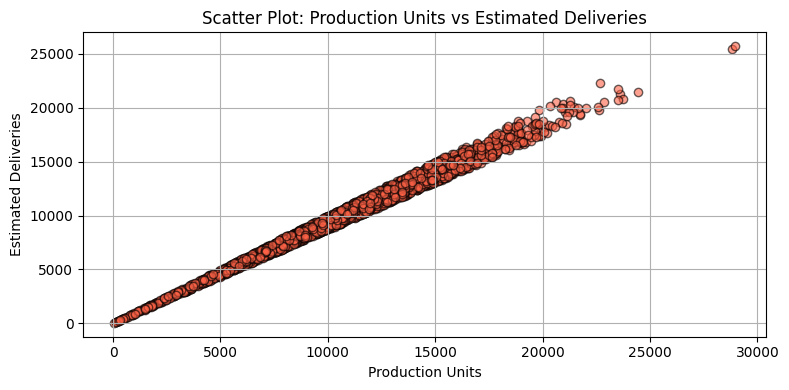

In [ ]:
# Scatter: Estimated Deliveries vs Production Units  (fixed: axis labels were swapped)
plt.figure(figsize=(8, 4))
plt.scatter(df['Production_Units'], df['Estimated_Deliveries'],
            color='tomato', edgecolor='black', alpha=0.6)
plt.title('Scatter Plot: Production Units vs Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.grid(True)
plt.tight_layout()
plt.show()

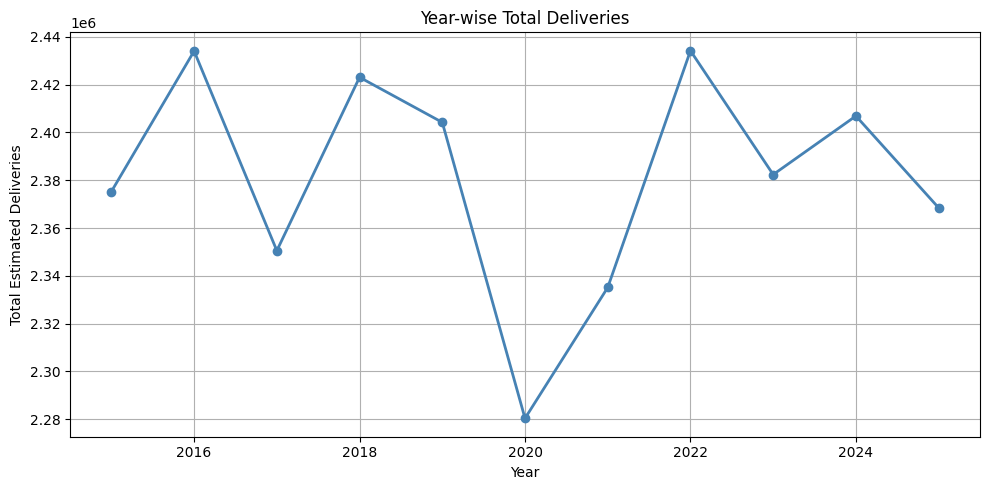

In [ ]:
# Year-wise delivery growth
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()
plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly.values, marker='o', color='steelblue', linewidth=2)
plt.title('Year-wise Total Deliveries')
plt.xlabel('Year')
plt.ylabel('Total Estimated Deliveries')
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2335/2790713128.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region, x='Region', y='Estimated_Deliveries', palette='viridis')


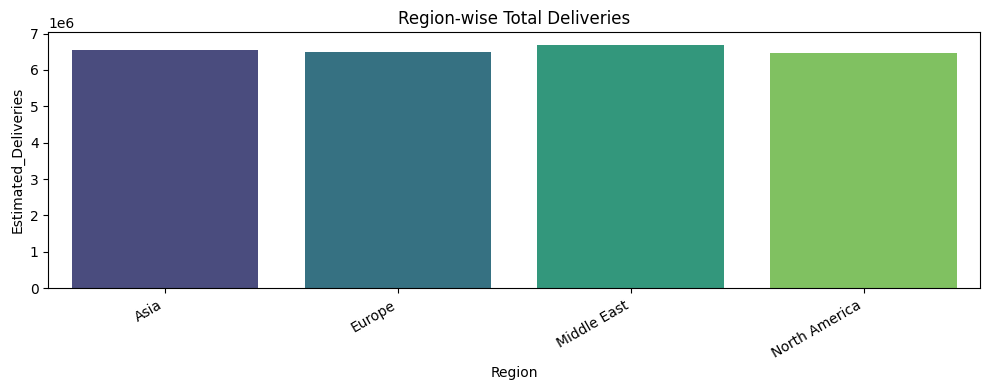

In [ ]:
# Region-wise performance  (fixed: seaborn >=0.13 deprecates positional x/y)
region = df.groupby('Region')['Estimated_Deliveries'].sum().reset_index()
plt.figure(figsize=(10, 4))
sns.barplot(data=region, x='Region', y='Estimated_Deliveries', palette='viridis')
plt.title('Region-wise Total Deliveries')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2335/1227244968.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_sales, x='Model', y='Estimated_Deliveries', palette='magma')


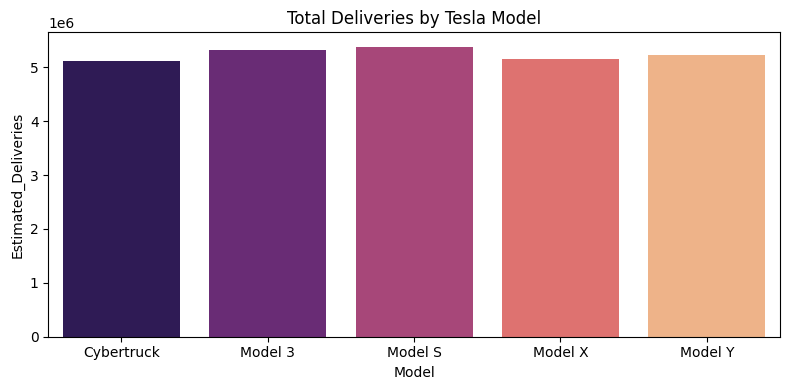

In [ ]:
# Best-selling Tesla models
model_sales = df.groupby('Model')['Estimated_Deliveries'].sum().reset_index()
plt.figure(figsize=(8, 4))
sns.barplot(data=model_sales, x='Model', y='Estimated_Deliveries', palette='magma')
plt.title('Total Deliveries by Tesla Model')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2335/3327281743.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=df, palette='coolwarm')


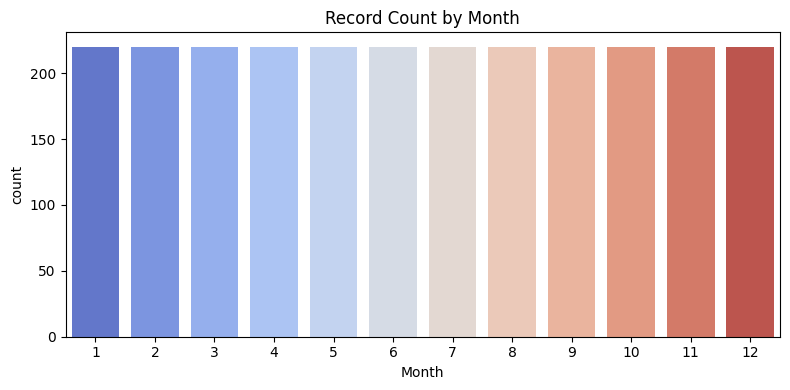

In [ ]:
# Monthly distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='Month', data=df, palette='coolwarm')
plt.title('Record Count by Month')
plt.tight_layout()
plt.show()

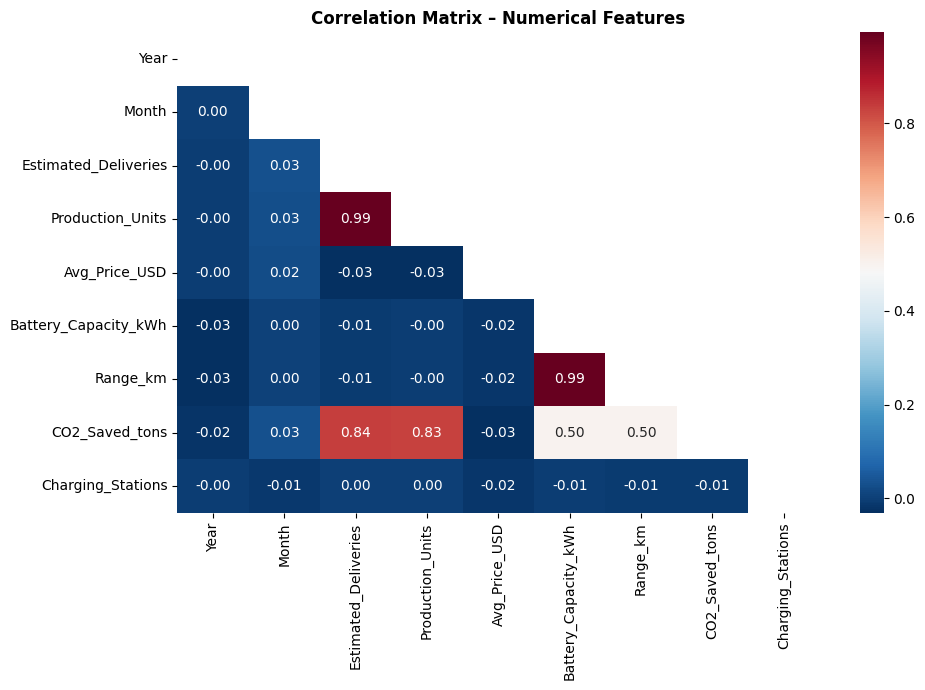

In [ ]:
# Correlation heatmap  (fixed: df.corr and np.triu both had missing () calls)
num_cols = ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', mask=mask)
plt.title('Correlation Matrix – Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

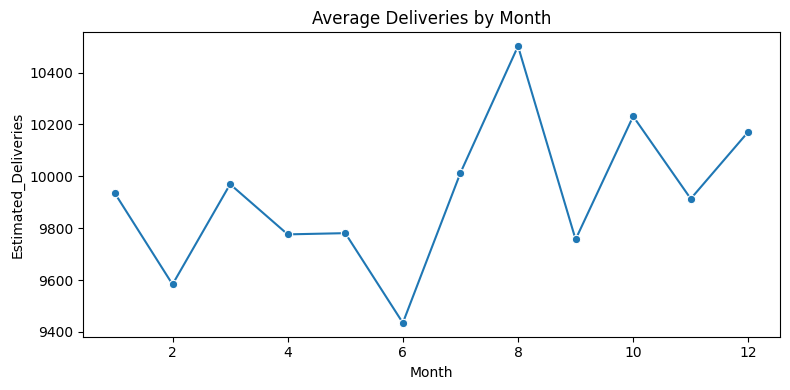

In [ ]:
# Monthly avg deliveries
monthly = df.groupby('Month')['Estimated_Deliveries'].mean().reset_index()
plt.figure(figsize=(8, 4))
sns.lineplot(data=monthly, x='Month', y='Estimated_Deliveries', marker='o')
plt.title('Average Deliveries by Month')
plt.tight_layout()
plt.show()

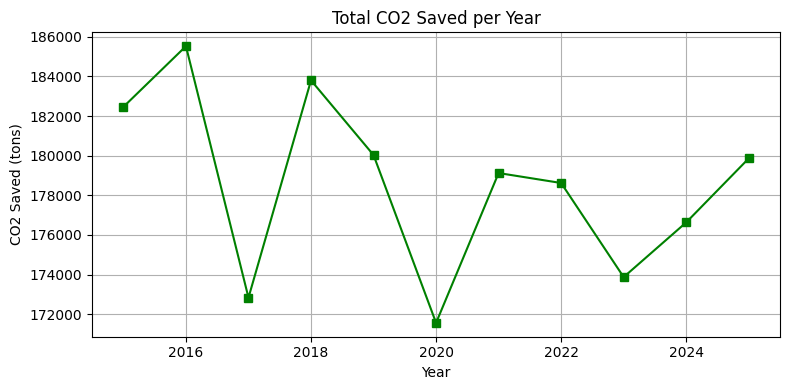

In [ ]:
# Yearly CO2 savings
yearly_co2 = df.groupby('Year')['CO2_Saved_tons'].sum()
plt.figure(figsize=(8, 4))
plt.plot(yearly_co2.index, yearly_co2.values, marker='s', color='green')
plt.title('Total CO2 Saved per Year')
plt.xlabel('Year'); plt.ylabel('CO2 Saved (tons)')
plt.grid(True); plt.tight_layout()
plt.show()

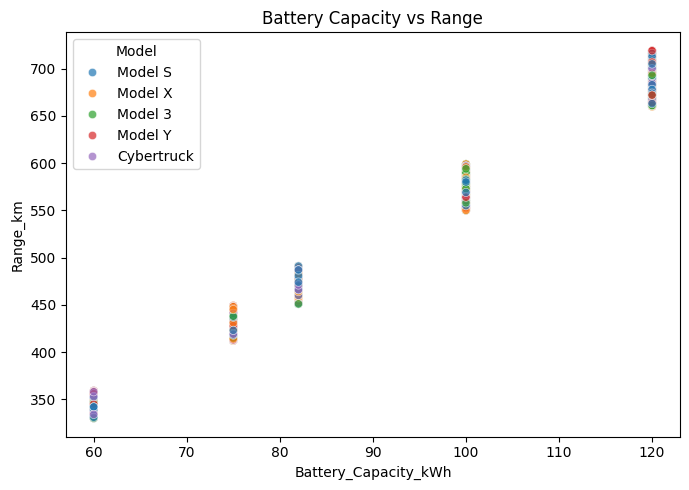

In [ ]:
# Battery capacity vs range
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Battery_Capacity_kWh', y='Range_km', data=df,
                hue='Model', palette='tab10', alpha=0.7)
plt.title('Battery Capacity vs Range')
plt.tight_layout()
plt.show()

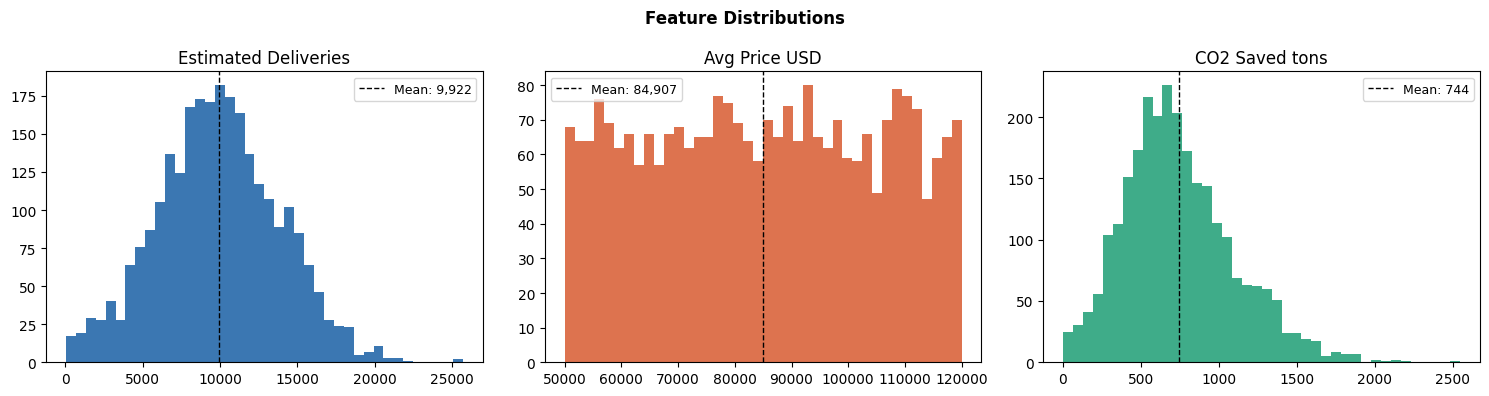

In [ ]:
# Feature distribution plots  (fixed: removed trailing empty string causing KeyError)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes,
        ['Estimated_Deliveries', 'Avg_Price_USD', 'CO2_Saved_tons'],
        ['#185FA5', '#D85A30', '#1D9E75']):
    ax.hist(df[col], bins=40, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1,
               label=f'Mean: {df[col].mean():,.0f}')
    ax.set_title(col.replace('_', ' '))
    ax.legend(fontsize=9)
plt.suptitle('Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

# Regression Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ['Year', 'Month', 'Region_enc', 'Model_enc', 'Production_Units',
            'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
            'Charging_Stations', 'Delivery_Production_Ratio']
target = 'Estimated_Deliveries'

df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Train size: 2112 | Test size: 528


In [ ]:
models = {
    'Linear Regression':    LinearRegression(),
    'Random Forest':        RandomForestRegressor(random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2   = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f'{name:25s} | MAE: {mae:>10,.0f} | RMSE: {rmse:>10,.0f} | R²: {r2:.4f}')

results_df = pd.DataFrame(results).T
results_df

Linear Regression         | MAE:        109 | RMSE:        153 | R²: 0.9984
Random Forest             | MAE:         65 | RMSE:        108 | R²: 0.9992
Gradient Boosting         | MAE:         70 | RMSE:         99 | R²: 0.9993


,MAE,RMSE,R2
Linear Regression,109.017410,153.484357,0.998420
Random Forest,64.862045,108.316732,0.999213
Gradient Boosting,70.272734,98.688803,0.999347


/tmp/ipykernel_2335/3714936528.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')


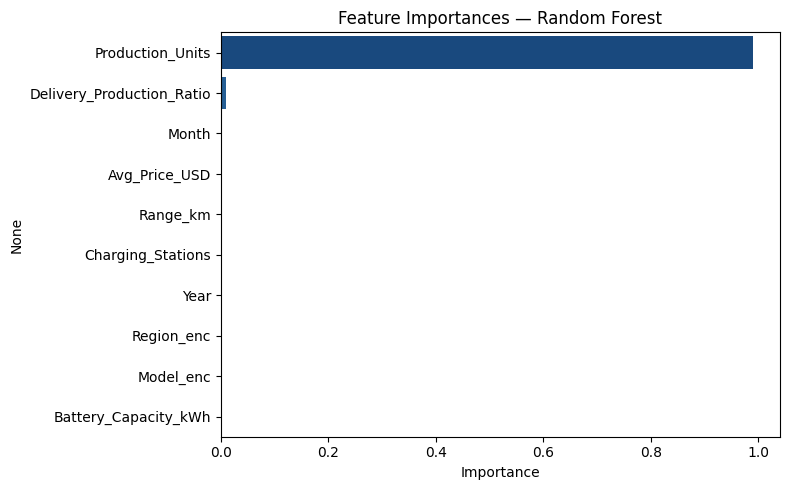

In [ ]:
# Feature importance from Random Forest
rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')
plt.title('Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [5, 10, None],
    'min_samples_split': [2, 5]
}

gs = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
gs.fit(X_train, y_train)

print('Best parameters:', gs.best_params_)
print(f'Best CV R²:      {gs.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²:      0.9986


Tuned Random Forest — Test Set Metrics
  MAE :         64
  RMSE:        109
  R²  : 0.9992


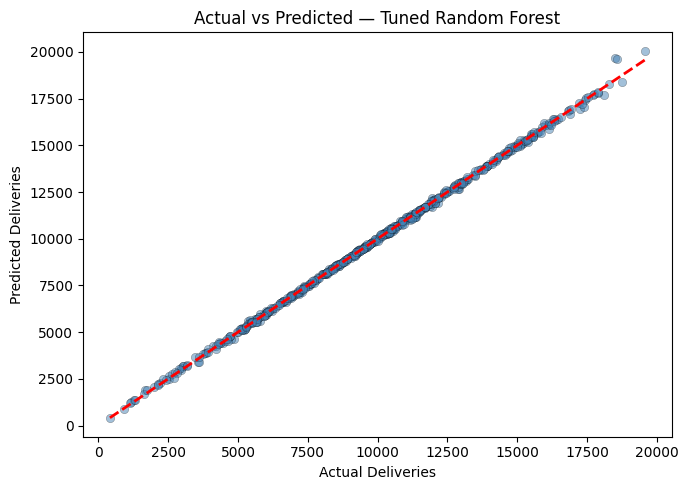

In [ ]:
# Evaluate tuned model on test set
best_rf = gs.best_estimator_
best_preds = best_rf.predict(X_test)

print('Tuned Random Forest — Test Set Metrics')
print(f'  MAE : {mean_absolute_error(y_test, best_preds):>10,.0f}')
print(f'  RMSE: {mean_squared_error(y_test, best_preds)**0.5:>10,.0f}')
print(f'  R²  : {r2_score(y_test, best_preds):.4f}')

# Actual vs Predicted plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_preds, alpha=0.5, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title('Actual vs Predicted — Tuned Random Forest')
plt.tight_layout()
plt.show()

# Time Series Forecasting

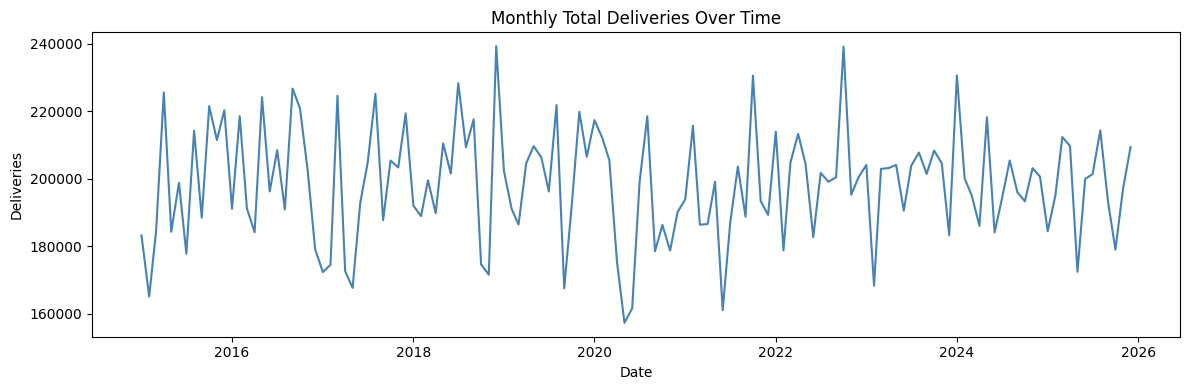

In [ ]:
# Aggregate monthly total deliveries across all regions/models
ts = (df.groupby(['Year', 'Month'])['Estimated_Deliveries']
        .sum()
        .reset_index())
ts['Date'] = pd.to_datetime(ts[['Year', 'Month']].assign(Day=1))
ts = ts.set_index('Date').sort_index()[['Estimated_Deliveries']]

plt.figure(figsize=(12, 4))
plt.plot(ts.index, ts['Estimated_Deliveries'], color='steelblue')
plt.title('Monthly Total Deliveries Over Time')
plt.xlabel('Date'); plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()

In [ ]:
# Build lag features for time series regression
ts_feat = ts.copy()
for lag in [1, 2, 3, 6, 12]:
    ts_feat[f'lag_{lag}'] = ts_feat['Estimated_Deliveries'].shift(lag)

ts_feat['month_num'] = ts_feat.index.month
ts_feat['year']      = ts_feat.index.year
ts_feat = ts_feat.dropna()

X_ts = ts_feat.drop('Estimated_Deliveries', axis=1)
y_ts = ts_feat['Estimated_Deliveries']

# Chronological train/test split (no shuffle)
split = int(len(X_ts) * 0.8)
X_tr, X_te = X_ts.iloc[:split], X_ts.iloc[split:]
y_tr, y_te = y_ts.iloc[:split], y_ts.iloc[split:]

ts_model = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
ts_model.fit(X_tr, y_tr)
ts_preds = ts_model.predict(X_te)

print('Time Series Forecasting — Test Metrics')
print(f'  MAE : {mean_absolute_error(y_te, ts_preds):>10,.0f}')
print(f'  RMSE: {mean_squared_error(y_te, ts_preds)**0.5:>10,.0f}')
print(f'  R²  : {r2_score(y_te, ts_preds):.4f}')

Time Series Forecasting — Test Metrics
  MAE :     10,770
  RMSE:     13,637
  R²  : -0.1360


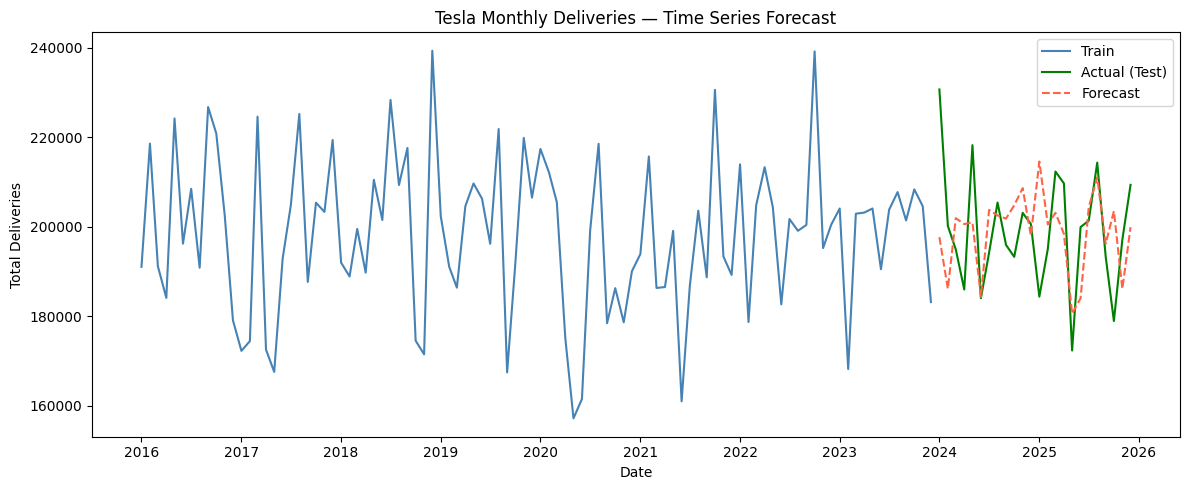

In [ ]:
# Forecast vs Actual plot
plt.figure(figsize=(12, 5))
plt.plot(y_tr.index, y_tr.values, label='Train', color='steelblue')
plt.plot(y_te.index, y_te.values, label='Actual (Test)', color='green')
plt.plot(y_te.index, ts_preds,    label='Forecast',      color='tomato', linestyle='--')
plt.title('Tesla Monthly Deliveries — Time Series Forecast')
plt.xlabel('Date'); plt.ylabel('Total Deliveries')
plt.legend()
plt.tight_layout()
plt.show()